<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분(1)   43 non-null     object 
 1   구분(2)   43 non-null     object 
 2   구분(3)   43 non-null     object 
 3   2020    43 non-null     float64
 4   2021    43 non-null     float64
 5   2022    43 non-null     float64
dtypes: float64(3), object(3)
memory usage: 2.1+ KB
총배출량  : 7억 2,429만 4천tCO₂eq. /'22일기준
1인당 배출량  : 14.017톤CO2eq/인 /'22일기준


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\ana

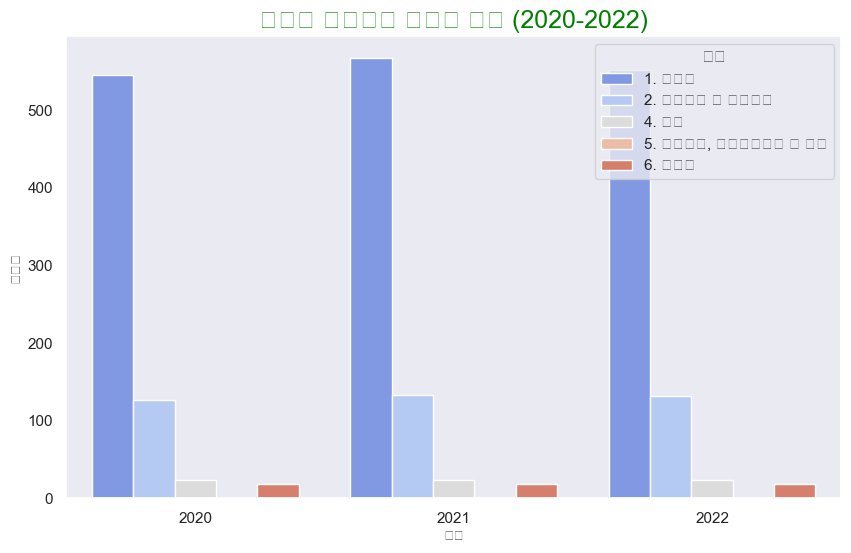

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests 
from bs4 import BeautifulSoup as bs
import lxml
import os

# 데이터 수집
df = pd.read_csv("./data/온실가스_분야별_추이.csv", encoding="utf-8")

#전처리 진행 
#데이터 프레임의 정보
df.info()
#데이터 프레임 결측치 확인
df.isnull().sum()
# 소계를 나타내는 행 삭제
df = df[(df['구분(2)'] != '소계')]
df.drop(3, axis =0, inplace=True)
df.drop(9, axis =0, inplace=True)
df.drop(33, axis=0, inplace=True)
#소계 나타내는 행 있는지 확인
df[df['구분(2)'] == '소계']
df.rename(columns = {'구분(1)' : '분야', "구분(2)":'중분류', "구분(3)":'세부분류'}, inplace=True)
df.head()

# 데이터 분석 
# 분야로 데이터 그룹화하기
groupdata = df.groupby("분야")[['2020','2021','2022']].sum()
groupdata['2020'] = pd.to_numeric(groupdata['2020'], errors='coerce')
groupdata['2021'] = pd.to_numeric(groupdata['2021'], errors='coerce')
groupdata['2022'] = pd.to_numeric(groupdata['2022'], errors='coerce')
# 음수인 배출량은 0으로 대체하기 
groupdata.loc[groupdata['2020'] < 0, '2020'] = 0
groupdata.loc[groupdata['2021'] < 0, '2021'] = 0
groupdata.loc[groupdata['2022'] < 0, '2022'] = 0
# 그래프에서 hue 속성을 쓰기 위해 dataframe 만들기
df1 = groupdata.stack().reset_index()
df1.columns = ['분야','연도','배출량']
df1['연도']  = df1['연도'].astype(int)

#웹 크롤링/스크래핑
# 총 탄소배출량과 1인당 탄소배출량에 대해서 알아보기 
url = 'https://search.naver.com/search.naver?where=nexearch&sm=top_hty&fbm=0&ie=utf8&query=온실가스+배출량+현황+그래프&ackey=y69th97f'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36'}
res = requests.get(url, headers=headers)
res.raise_for_status()
soup = bs(res.text, 'html.parser')
#온실가스 배출량 및 1인당 배출량 알아보기 위해 반복문 활용하여 적절히 출력함. 
div_text = soup.select(".text")
for div in div_text[:2]:
    title = div.contents[0]  # '총배출량' 같은 제목
    value = div.find('em').get_text()       # 수치
    year = div.find('span').get_text()  # 연도
    print(f"{title} : {value} /{year}일기준")
    
#시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(10,6))
sns.set_theme(style="dark")
sns.barplot(data=df1, x='연도', y='배출량', hue='분야', palette="coolwarm")
plt.title('분야별 온실가스 배출량 추이 (2020-2022)', fontsize = 18, color = 'green')
plt.xlabel('연도', fontsize = 10)
plt.ylabel('배출량',fontsize = 10)
plt.show()